imports

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.io import read_image

In [59]:
transform=transforms.Compose([
    transforms.ToTensor()
])
train_dataset=datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test_dataset=train_dataset=datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Files already downloaded and verified
Files already downloaded and verified


In [60]:
train_loader=DataLoader(train_dataset, shuffle=True, batch_size=64)
test_loader=DataLoader(test_dataset, shuffle=False, batch_size=64)

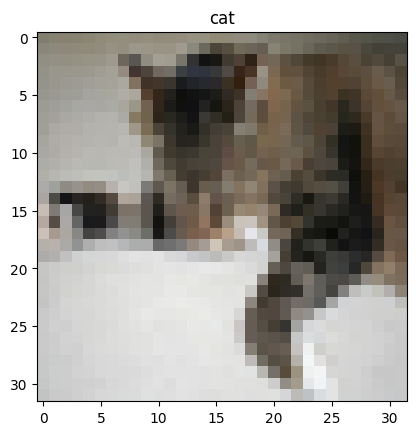

In [61]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1,2,0))
plt.title(classes[labels[0]])
plt.show()

In [62]:
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Conv2d(3,16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    
    def forward(self, x):
        x=self.backbone(x)
        x=self.classifier(x)
        return x
        

In [63]:
device=torch.device('cuda')
model=CNNmodel().to(device)
criteration=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)


In [64]:
for epoch in range(50):
    runningloss=0
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        prediction=model(images)
        loss=criteration(prediction,labels)
        loss.backward()
        optimizer.step()
        runningloss+=loss.item()
    batchloss=runningloss/len(train_loader)
    print(f'epoch: {epoch+1}/50')
    print(f'loss: {batchloss}')

epoch: 1/100
loss: 1.9935119000210124
epoch: 2/100
loss: 1.6529055066928742
epoch: 3/100
loss: 1.52479174941968
epoch: 4/100
loss: 1.4406181869992785
epoch: 5/100
loss: 1.3638038927582419
epoch: 6/100
loss: 1.2964051293719345
epoch: 7/100
loss: 1.2513750522000016
epoch: 8/100
loss: 1.1898377974321888
epoch: 9/100
loss: 1.1284699246382257
epoch: 10/100
loss: 1.0765470258749215
epoch: 11/100
loss: 1.0354335049914707
epoch: 12/100
loss: 0.9920953470430557


KeyboardInterrupt: 

In [ ]:
torch.cuda.empty_cache()

In [ ]:
model.eval()
runningloss=0
with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        prediction=model(images)
        loss=criteration(prediction, labels)
        runningloss+=loss.item()
    averageloss=runningloss/len(test_dataset)
print(f'loss: {loss}')


loss: 2.6336238079238683e-05


In [ ]:
image=read_image("./cat2.png")
transofrmed=transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ConvertImageDtype(torch.float),
    ]
)
timg=transofrmed(image)
timg=timg.to(device).unsqueeze(0)
print(timg.shape)
softmax=nn.Softmax(dim=1)
predict=softmax(model(timg))
classs=torch.argmax(predict, dim=1).item()
print(classes[classs])

torch.Size([1, 3, 32, 32])
cat
